### Otimização de ROI de Marketing: Predição de Viralidade em Redes Sociais

### 1 - Contexto do Projeto
No cenário atual das redes sociais, a diferença entre um post comum e um conteúdo viral pode representar uma economia de milhares de reais em tráfego pago e um aumento exponencial no brand awareness. Este projeto utiliza técnicas avançadas de Ciência de Dados e Machine Learning para identificar padrões e prever o potencial de viralização de conteúdos antes mesmo de serem publicados.

#### O Problema de Negócio

As equipes de marketing enfrentam incertezas sobre qual tipo de conteúdo (vídeo, foto, texto) ou qual temática performa melhor em diferentes plataformas. O objetivo aqui é reduzir o desperdício de recursos focando em produções com maior probabilidade de alto alcance orgânico.

### 2 - Metodologia Científica
O desenvolvimento do estudo seguiu as etapas do framework CRISP-DM, focando em:

- Exploração e Sanidade: Validação de integridade do dataset (verificação de nulos e outliers).

- Feature Engineering: Extração de inteligência temporal (sazonalidade) e processamento de hashtags através de MultiLabelBinarization.

- Balanceamento de Classes: Tratamento de viés de dados utilizando técnicas de Undersampling para garantir que o modelo aprenda a distinguir posts virais de não-virais de forma justa.

- Modelagem Preditiva: Implementação de algoritmos de Árvore de Decisão (Decision Trees), priorizando a interpretabilidade dos pesos das variáveis.

### 3 - Stack Tecnológica
Linguagem: Python 3.10+

Manipulação de Dados: Pandas, NumPy

Visualização: Matplotlib, Seaborn

Machine Learning: Scikit-Learn, Imbalanced-learn (Imblearn)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')


df = pd.read_csv('social_media_viral_content_dataset.csv')
df.head()

,post_id,platform,content_type,topic,language,region,post_datetime,hashtags,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral
0,SM_100000,Instagram,text,Sports,ur,UK,2024-12-10 00:00:00,#tech #funny #music,2319102,122058,15800,861,0.0598,0.464,1
1,SM_100001,Instagram,carousel,Sports,ur,Brazil,2024-10-13 00:00:00,#news #fyp #funny #ai #trending,2538464,110368,11289,54887,0.0695,-0.800,1
2,SM_100002,YouTube Shorts,video,Technology,ur,UK,2024-05-03 00:00:00,#ai #news,1051176,87598,47196,44132,0.1702,0.416,0
3,SM_100003,X,text,Politics,ur,US,2024-08-04 00:00:00,#ai #funny,5271440,329465,774,59736,0.0740,0.877,1
4,SM_100004,YouTube Shorts,text,Education,es,US,2024-03-28 00:00:00,#news #ai #viral #funny #fyp,3186256,199141,5316,83105,0.0903,0.223,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          2000 non-null   object 
 1   platform         2000 non-null   object 
 2   content_type     2000 non-null   object 
 3   topic            2000 non-null   object 
 4   language         2000 non-null   object 
 5   region           2000 non-null   object 
 6   post_datetime    2000 non-null   object 
 7   hashtags         2000 non-null   object 
 8   views            2000 non-null   int64  
 9   likes            2000 non-null   int64  
 10  comments         2000 non-null   int64  
 11  shares           2000 non-null   int64  
 12  engagement_rate  2000 non-null   float64
 13  sentiment_score  2000 non-null   float64
 14  is_viral         2000 non-null   int64  
dtypes: float64(2), int64(5), object(8)
memory usage: 234.5+ KB


In [4]:
df[[ 'views','likes', 'comments', 'shares']].describe()

,views,likes,comments,shares
count,2.000000e+03,2000.000000,2000.000000,2000.000000
mean,4.284860e+06,245329.244000,24786.929000,49936.981500
std,3.246193e+06,145032.423582,14433.288364,29012.818697
min,4.380000e+03,292.000000,14.000000,127.000000
25%,1.652742e+06,118903.750000,12337.750000,25698.750000
50%,3.469408e+06,239831.000000,24519.500000,50212.000000
75%,6.348078e+06,372323.500000,37116.250000,75433.000000
max,1.437179e+07,499983.000000,49989.000000,99977.000000


Referente as colunas:




In [5]:
print(f"Maior numero de views de registrados em um post: {max(df['views'])}")
print(f"Menor numero de views de registrados em um post: {min(df['views'])}")
print(f"Média de views registrados em um post: {df['views'].mean()}")

Maior numero de views de registrados em um post: 14371791
Menor numero de views de registrados em um post: 4380
Média de views registrados em um post: 4284859.5715


In [6]:
df.isnull().sum()

post_id            0
platform           0
content_type       0
topic              0
language           0
region             0
post_datetime      0
hashtags           0
views              0
likes              0
comments           0
shares             0
engagement_rate    0
sentiment_score    0
is_viral           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

### stap 1

Já garantir que não precisamos nos preocupar com registros Null.

Tivemos uma minima visão da disperção dos dados que são ints.

In [8]:
quant_reg_viral = df[df['is_viral'] == 1].shape[0]
porcentagem_de_posts_virais = quant_reg_viral / df.shape[0] * 100
print(f"Porcentagem de posts virais: {porcentagem_de_posts_virais:.2f}%")


Porcentagem de posts virais: 69.90%


### stap 2 

Sabemos agora que o dataset não está com um numero balaceado em volume de classificação positiva e negativa.

Por conta disso vamos precisa tomar cuidado no momento de separar o volume de amostrar para treino para que o desbalanceamento não prejudique o treinamento.

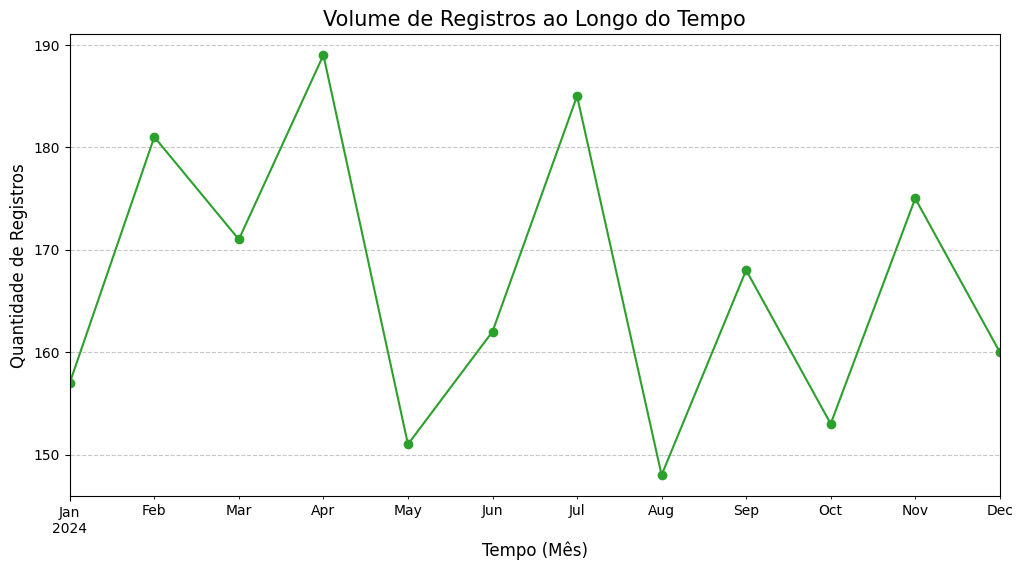

In [9]:
df['post_datetime'] = df['post_datetime'].astype('datetime64[ns]')

contagem_temporal = df.groupby(df['post_datetime'].dt.to_period("M")).size()

# 3. Plotar o gráfico
plt.figure(figsize=(12, 6))
contagem_temporal.plot(kind='line', marker='o', color='#2ca02c')

plt.title('Volume de Registros ao Longo do Tempo', fontsize=15)
plt.xlabel('Tempo (Mês)', fontsize=12)
plt.ylabel('Quantidade de Registros', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [10]:
print(df['platform'].unique())

['Instagram' 'YouTube Shorts' 'X' 'TikTok']


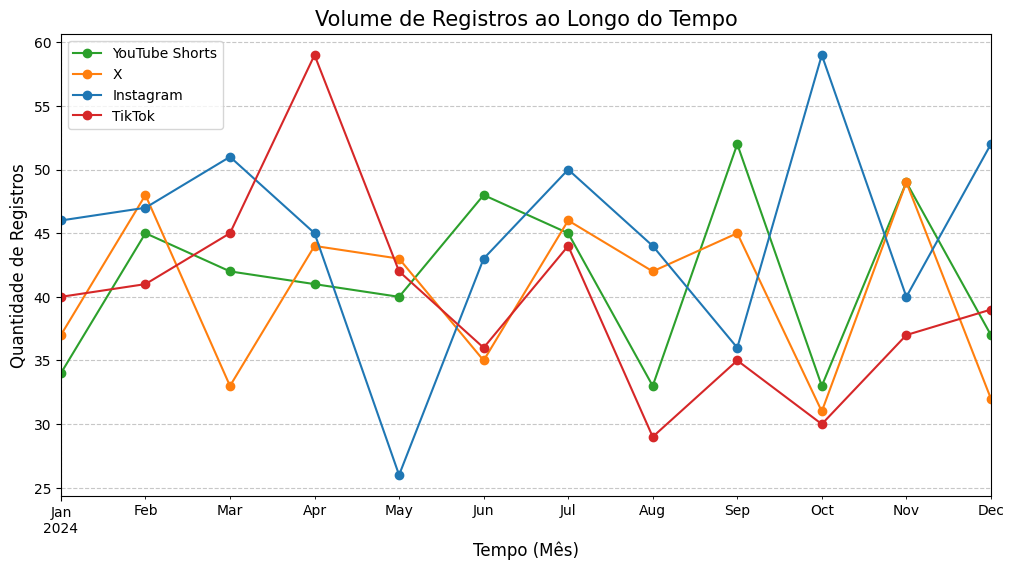

In [11]:
df_youtube = df[df['platform'] == 'YouTube Shorts']
df_x = df[df['platform'] == 'X']
df_instagram = df[df['platform'] == 'Instagram']
df_tiktok = df[df['platform'] == 'TikTok']


contagem_temporal1 = df_youtube.groupby(df_youtube['post_datetime'].dt.to_period("M")).size()
contagem_temporal2 = df_x.groupby(df_x['post_datetime'].dt.to_period("M")).size()
contagem_temporal3 = df_instagram.groupby(df_instagram['post_datetime'].dt.to_period("M")).size()
contagem_temporal4 = df_tiktok.groupby(df_tiktok['post_datetime'].dt.to_period("M")).size()

# 3. Plotar o gráfico
plt.figure(figsize=(12, 6))
contagem_temporal1.plot(kind='line', marker='o', color='#2ca02c')
contagem_temporal2.plot(kind='line', marker='o', color='#ff7f0e')
contagem_temporal3.plot(kind='line', marker='o', color='#1f77b4')
contagem_temporal4.plot(kind='line', marker='o', color='#d62728')

plt.legend(['YouTube Shorts', 'X', 'Instagram', 'TikTok'])
plt.title('Volume de Registros ao Longo do Tempo', fontsize=15)
plt.xlabel('Tempo (Mês)', fontsize=12)
plt.ylabel('Quantidade de Registros', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [12]:
df_quant_viral_plataforma = pd.DataFrame({
    'YouTube Shorts': [df_youtube[df_youtube['is_viral'] == 1].shape[0], df_youtube.shape[0]],
    'X': [df_x[df_x['is_viral'] == 1].shape[0], df_x.shape[0]],
    'Instagram': [df_instagram[df_instagram['is_viral'] == 1].shape[0], df_instagram.shape[0]],
    'TikTok': [df_tiktok[df_tiktok['is_viral'] == 1].shape[0], df_tiktok.shape[0]]
}, index=['Quantidade de Posts Virais', 'Total de Posts'])

df_quant_viral_plataforma.loc['Taxa de Viralização (%)'] = (
    df_quant_viral_plataforma.loc['Quantidade de Posts Virais'] / 
    df_quant_viral_plataforma.loc['Total de Posts'] * 100
).round(2)

df_quant_viral_plataforma.head()

,YouTube Shorts,X,Instagram,TikTok
Quantidade de Posts Virais,343.00,338.00,382.00,335.00
Total de Posts,499.00,485.00,539.00,477.00
Taxa de Viralização (%),68.74,69.69,70.87,70.23


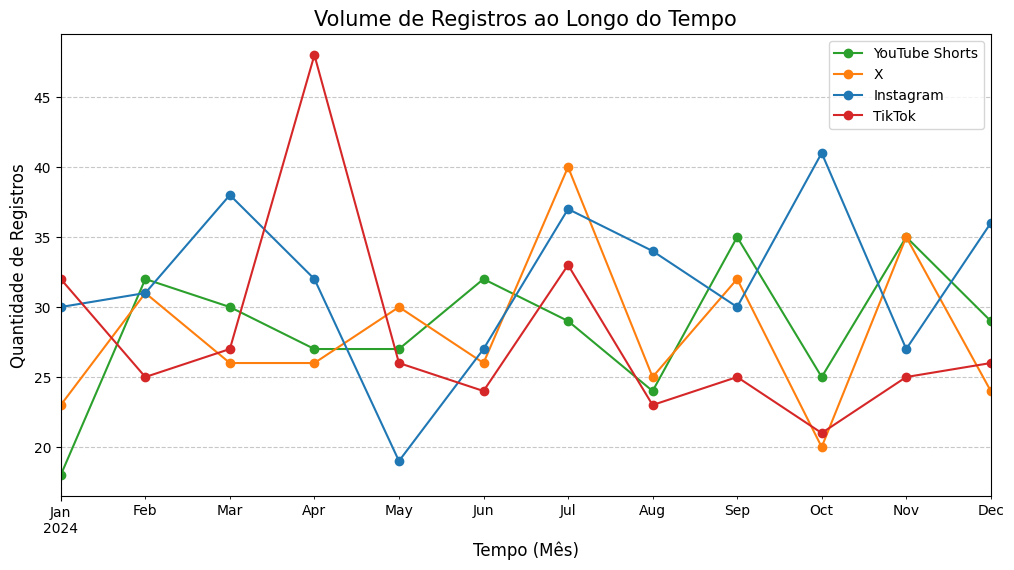

In [13]:
df_youtube = df_youtube[df_youtube['is_viral'] == 1]
df_x = df_x[df_x['is_viral'] == 1]
df_instagram = df_instagram[df_instagram['is_viral'] == 1]
df_tiktok = df_tiktok[df_tiktok['is_viral'] == 1]



contagem_temporal1 = df_youtube.groupby(df_youtube['post_datetime'].dt.to_period("M")).size()
contagem_temporal2 = df_x.groupby(df_x['post_datetime'].dt.to_period("M")).size()
contagem_temporal3 = df_instagram.groupby(df_instagram['post_datetime'].dt.to_period("M")).size()
contagem_temporal4 = df_tiktok.groupby(df_tiktok['post_datetime'].dt.to_period("M")).size()

# 3. Plotar o gráfico
plt.figure(figsize=(12, 6))
contagem_temporal1.plot(kind='line', marker='o', color='#2ca02c')
contagem_temporal2.plot(kind='line', marker='o', color='#ff7f0e')
contagem_temporal3.plot(kind='line', marker='o', color='#1f77b4')
contagem_temporal4.plot(kind='line', marker='o', color='#d62728')

plt.legend(['YouTube Shorts', 'X', 'Instagram', 'TikTok'])
plt.title('Volume de Registros ao Longo do Tempo', fontsize=15)
plt.xlabel('Tempo (Mês)', fontsize=12)
plt.ylabel('Quantidade de Registros', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Stap 3 

Conseguimos observar que por mais que os dados estejam desbalanceados no que se refere a volume de positivos e negativos, exite a mesma proporção de dados de classificação para cada rede social analisada, o que me tranquiliza a um possivel vies decorrente a volume de dados do dataset. 

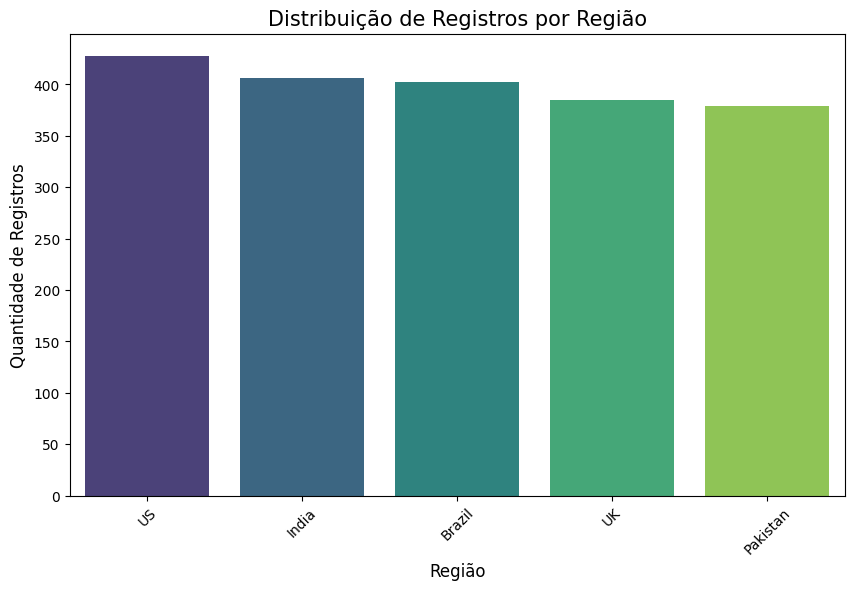

In [14]:
df['region'].unique()


plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='region', order=df['region'].value_counts().index, palette='viridis')
plt.title('Distribuição de Registros por Região', fontsize=15)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Quantidade de Registros', fontsize=12)
plt.xticks(rotation=45)
plt.show();

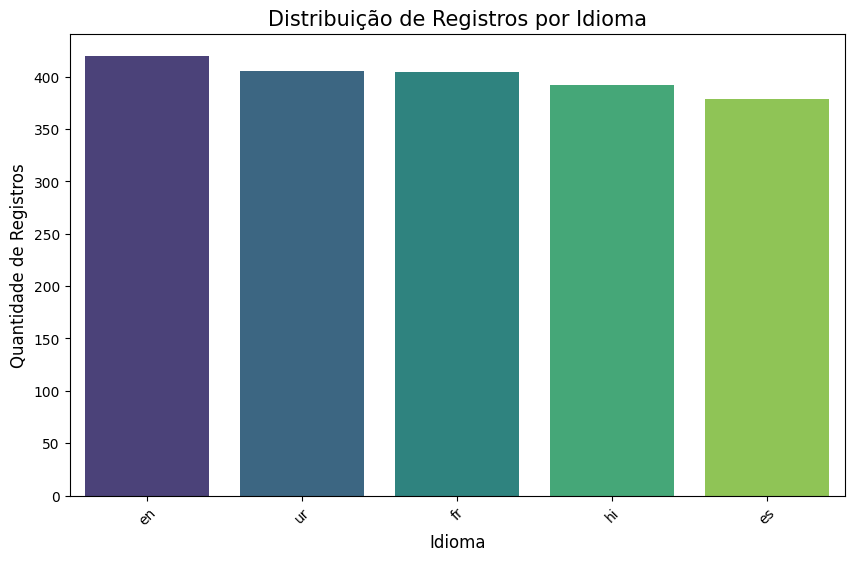

In [15]:
df['language'].unique()

    
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='language', order=df['language'].value_counts().index, palette='viridis')
plt.title('Distribuição de Registros por Idioma', fontsize=15)
plt.xlabel('Idioma', fontsize=12)
plt.ylabel('Quantidade de Registros', fontsize=12)
plt.xticks(rotation=45)
plt.show()

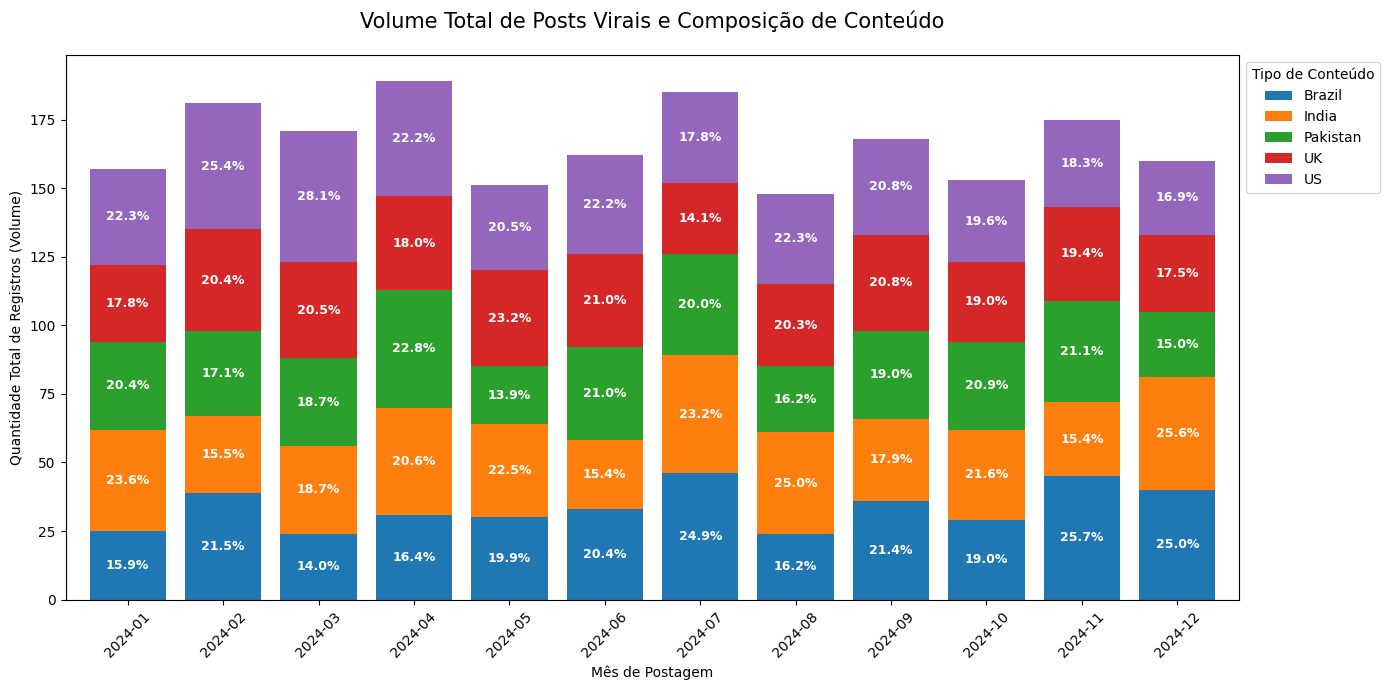

In [16]:

import matplotlib.pyplot as plt

agrupado = df.groupby([df['post_datetime'].dt.to_period("M"), 'region']).size()
df_evolucao = agrupado.unstack(fill_value=0)

df_perc = df_evolucao.div(df_evolucao.sum(axis=1), axis=0) * 100

ax = df_evolucao.plot(kind='bar', stacked=True, figsize=(14, 7), width=0.8)

for i, mes in enumerate(df_evolucao.index):
    offset = 0  
    for coluna in df_evolucao.columns:
        valor_abs = df_evolucao.loc[mes, coluna]
        porcentagem = df_perc.loc[mes, coluna]
        
        if porcentagem > 2: 
            
            ax.text(i, 
                    offset + (valor_abs / 2), 
                    f'{porcentagem:.1f}%', 
                    ha='center', 
                    va='center', 
                    fontsize=9, 
                    color='white', 
                    fontweight='bold')
        
        offset += valor_abs  

plt.title('Volume Total de Posts Virais e Composição de Conteúdo', fontsize=15, pad=20)
plt.ylabel('Quantidade Total de Registros (Volume)')
plt.xlabel('Mês de Postagem')
plt.legend(title='Tipo de Conteúdo', bbox_to_anchor=(1.0, 1))
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

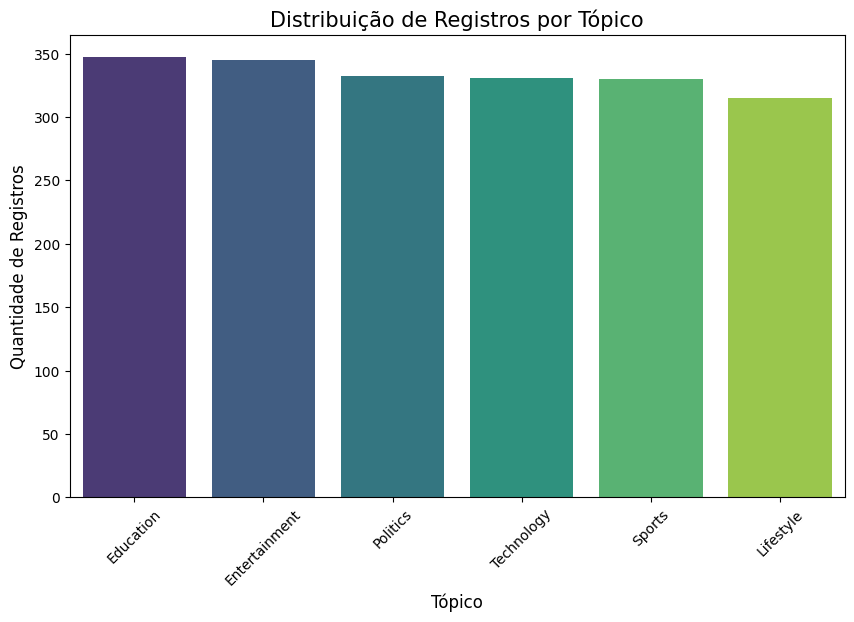

In [17]:
df['topic'].unique()

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='topic', order=df['topic'].value_counts().index, palette='viridis')
plt.title('Distribuição de Registros por Tópico', fontsize=15)
plt.xlabel('Tópico', fontsize=12)
plt.ylabel('Quantidade de Registros', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Constatações referente ao estudo dos dados

Pode ser percebido que as colunas que reference a dados de classificação demonstraram uma distribuição de dados adequadas para a analise, tendo em vista que possuem um volume equivalente para cada registro. E podemos afirmar que existe um volume consideravem de dados a mais classificados como viral e isso vai precisar ser ajustado no momento de retirar a amostra de treinamento. 
 
 O dataset:
 - Não possui campos NULL.
 - Não possui dados em branco.
 - Não possui outliers.
 - A coluna Views precisa ser retirada com ela tem uma correlação direta com viral.

# Tomada de decisão de qual modelo usar

Entendendo melhor os dados entendo que a necessidade aqui não é de apenas classificar bem cada novo registro, mas tambem ter uma boa explicabilidade de pq tivemos essa classificação para entender tambem o comportamento e os parametros que mais influenciam o post a ser viral.

Para isso faz sentido buscarmos modelos que tenham explicabilidade, nesse caso inicialmente considero tanto arvore de decisão quanto regressão logistica.

Para tratar o desbalaceamento utilizarei o undersempling pq na maioria dos casos prejudica menos o modelo do que realizarmos um oversempling e gerarmos dados para balacear.

Como o dataset não é massivo nesse caso usarei a arvore de decisão para esse caso de estudo.



In [18]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler

## Hipotese 1 

Desenvolver o modelo de modo a conseguir classificar o post como viral ou não, para que somente com as caracteristicas do video para direcionarmos os criadores de conteudos em que tipo de post realizar.

pra isso devemos desconsiderar as features que são registradas após a postagem do conteudo, pq aqui a intenção e mensurar a influencia que as caracteristicas dos post influenciam para a viralização.


In [19]:
# Pra fazer uso do referencia temporal da coluna post_datetime, preciso garantir que ela seja decomposta para trazer somente mes em int.

df['post_month'] = df['post_datetime'].dt.month


X = df.drop(columns=['post_id', 'is_viral', 'post_datetime', 'content_id', 'views', 'likes', 'comments', 'shares', 'engagement_rate', 'sentiment_score'], errors='ignore')
y = df['is_viral']

# Preciso tratar as variáveis categóricas
X = pd.get_dummies(X, drop_first=True)


X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Aplicando o Undersampling (Apenas no conjunto de TREINO)
rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train_raw, y_train_raw)

print(f"Volume original treino: {y_train_raw.value_counts().to_dict()}")
print(f"Volume após Undersampling: {y_train_res.value_counts().to_dict()}")

# Treino do Modelo de Árvore de Decisão
modelo = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo.fit(X_train_res, y_train_res)



Volume original treino: {1: 979, 0: 421}
Volume após Undersampling: {0: 421, 1: 421}


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [20]:
# Avaliação
y_pred = modelo.predict(X_test)
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))




Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.27      0.18      0.22       181
           1       0.69      0.79      0.74       419

    accuracy                           0.60       600
   macro avg       0.48      0.48      0.48       600
weighted avg       0.56      0.60      0.58       600



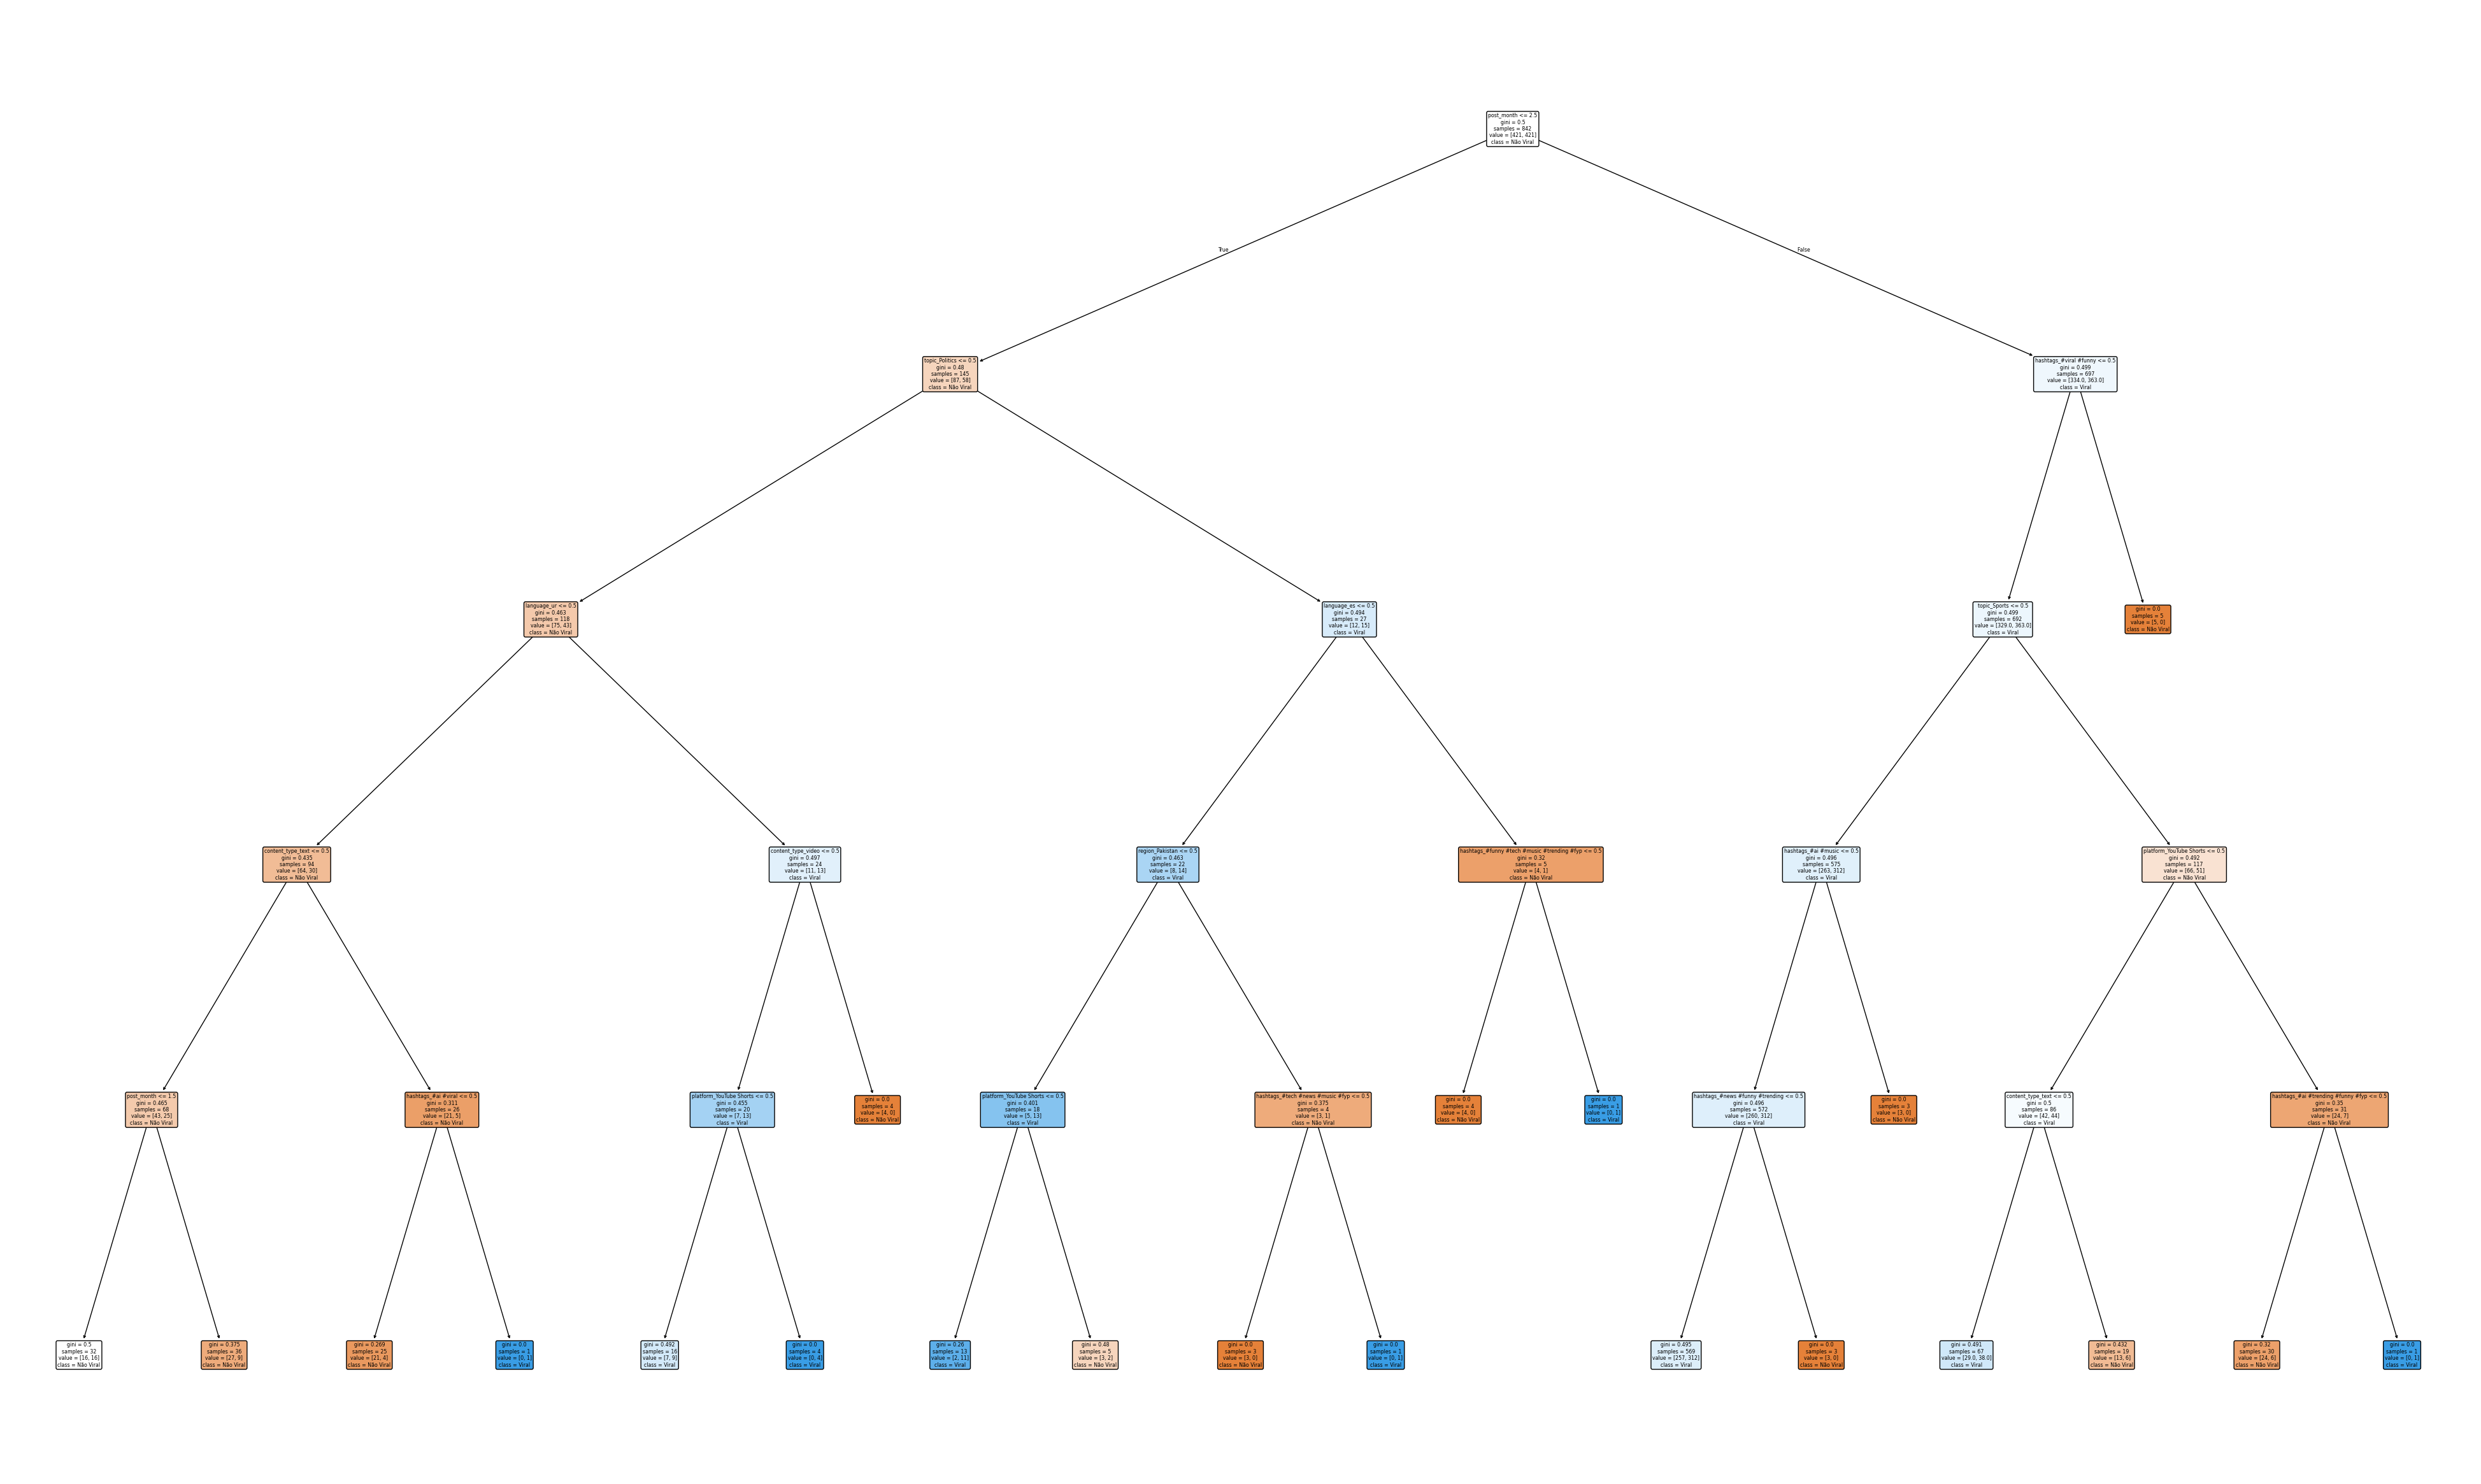

In [21]:
# Visualização da Árvore e Importância das Features
plt.figure(figsize=(50,30))
plot_tree(modelo, feature_names=X.columns, class_names=['Não Viral', 'Viral'], filled=True, rounded=True)
plt.show()


In [22]:
# Extração dos Pesos (Feature Importance)
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nPesos das Features (Importância):")
print(importancias.head(10))


Pesos das Features (Importância):
platform_YouTube Shorts            0.165548
post_month                         0.145724
content_type_text                  0.078480
content_type_video                 0.073023
hashtags_#viral #funny             0.070827
topic_Sports                       0.057401
language_ur                        0.049084
hashtags_#news #funny #trending    0.046524
hashtags_#ai #music                0.046038
topic_Politics                     0.041627
dtype: float64


## Observação

O resultado do modelo demonstrou ponto importantes! 

- Temos um volume de dados de caracteristicas baixas demais para determinarmos se um video viraliza ou não.
- O undersampling pode ter prejudicado o modelo pq acabou reduzindo consideravelmente o volume de dados de teste 40% em registros positivos.
- A arvore demonstrou um desbalanceamento notavel na sua estrutura o que é um ponto de atenção.

### Resultado da hipotese 1:

Esse dataset tem um numero baixo de caracteristicas e de registros para promover uma boa classificação e entendimento levando em conta somente dados referentes a produção do post.

## Hipotese 2:

Temos capacidade de analisar e interpretar a qualidade do post tendo em vista os dados que abrangem a receptividade do video quando postado na plataforma, podendo trazer valor em saber o que influencia mais o video a se tornar virar pensando no comportamento de quem assiste, assim devemos trazer para o treinamento os dados de likes, comentarios, compartilhamentos entre outros existente no dataset.


In [23]:
df_v2 = df.drop(columns=['post_id', 'post_datetime', 'content_id', 'views'], errors='ignore')
df_v2.head()

,platform,content_type,topic,language,region,hashtags,likes,comments,shares,engagement_rate,sentiment_score,is_viral,post_month
0,Instagram,text,Sports,ur,UK,#tech #funny #music,122058,15800,861,0.0598,0.464,1,12
1,Instagram,carousel,Sports,ur,Brazil,#news #fyp #funny #ai #trending,110368,11289,54887,0.0695,-0.800,1,10
2,YouTube Shorts,video,Technology,ur,UK,#ai #news,87598,47196,44132,0.1702,0.416,0,5
3,X,text,Politics,ur,US,#ai #funny,329465,774,59736,0.0740,0.877,1,8
4,YouTube Shorts,text,Education,es,US,#news #ai #viral #funny #fyp,199141,5316,83105,0.0903,0.223,1,3


In [24]:
from sklearn.preprocessing import MultiLabelBinarizer

df_v2['hashtags_list'] = df_v2['hashtags'].str.replace('#', '').str.split()


df_v2['hashtags_list'] = df_v2['hashtags_list'].apply(lambda d: d if isinstance(d, list) else [])
#df_v2 = df_v2.drop(columns=['hashtags'], errors='ignore')
df_v2.head()

,platform,content_type,topic,language,region,hashtags,likes,comments,shares,engagement_rate,sentiment_score,is_viral,post_month,hashtags_list
0,Instagram,text,Sports,ur,UK,#tech #funny #music,122058,15800,861,0.0598,0.464,1,12,"[tech, funny, music]"
1,Instagram,carousel,Sports,ur,Brazil,#news #fyp #funny #ai #trending,110368,11289,54887,0.0695,-0.800,1,10,"[news, fyp, funny, ai, trending]"
2,YouTube Shorts,video,Technology,ur,UK,#ai #news,87598,47196,44132,0.1702,0.416,0,5,"[ai, news]"
3,X,text,Politics,ur,US,#ai #funny,329465,774,59736,0.0740,0.877,1,8,"[ai, funny]"
4,YouTube Shorts,text,Education,es,US,#news #ai #viral #funny #fyp,199141,5316,83105,0.0903,0.223,1,3,"[news, ai, viral, funny, fyp]"


In [25]:
mlb = MultiLabelBinarizer()

df_hashtags = pd.DataFrame(
    mlb.fit_transform(df_v2['hashtags_list']),
    columns=mlb.classes_,
    index=df_v2.index
)

df_final = pd.concat([df_v2, df_hashtags], axis=1)

df_final = df_final.drop(columns=['hashtags', 'hashtags_list'])
df_final.head(10) 

,platform,content_type,topic,language,region,likes,comments,shares,engagement_rate,sentiment_score,is_viral,post_month,ai,funny,fyp,music,news,tech,trending,viral
0,Instagram,text,Sports,ur,UK,122058,15800,861,0.0598,0.464,1,12,0,1,0,1,0,1,0,0
1,Instagram,carousel,Sports,ur,Brazil,110368,11289,54887,0.0695,-0.800,1,10,1,1,1,0,1,0,1,0
2,YouTube Shorts,video,Technology,ur,UK,87598,47196,44132,0.1702,0.416,0,5,1,0,0,0,1,0,0,0
3,X,text,Politics,ur,US,329465,774,59736,0.0740,0.877,1,8,1,1,0,0,0,0,0,0
4,YouTube Shorts,text,Education,es,US,199141,5316,83105,0.0903,0.223,1,3,1,1,1,0,1,0,0,1
5,Instagram,carousel,Sports,hi,Brazil,465248,27485,25659,0.0796,-0.907,1,11,0,0,0,1,0,1,0,0
6,X,text,Education,hi,UK,2847,194,84655,1.3393,-0.235,0,6,1,0,0,0,0,1,0,0
7,X,text,Technology,es,Pakistan,329047,31556,11395,0.1256,0.215,1,7,0,0,0,0,1,1,1,0
8,YouTube Shorts,text,Sports,es,Pakistan,489592,14507,87314,0.1510,0.884,1,3,0,0,0,1,1,1,1,0
9,YouTube Shorts,video,Politics,en,US,239729,8438,43002,0.0934,-0.968,1,10,1,0,0,1,1,0,1,1


In [26]:
df = df_final
X = df.drop(columns=['post_id', 'is_viral', 'post_datetime', 'content_id', 'views'], errors='ignore')
y = df['is_viral']

# Preciso tratar as variáveis categóricas
X = pd.get_dummies(X, drop_first=True)


X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Aplicando o Undersampling (Apenas no conjunto de TREINO)
rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train_raw, y_train_raw)

print(f"Volume original treino: {y_train_raw.value_counts().to_dict()}")
print(f"Volume após Undersampling: {y_train_res.value_counts().to_dict()}")

# Treino do Modelo de Árvore de Decisão
modelo = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo.fit(X_train_res, y_train_res)



Volume original treino: {1: 979, 0: 421}
Volume após Undersampling: {0: 421, 1: 421}


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [27]:
# Avaliação
y_pred = modelo.predict(X_test)
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))




Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       181
           1       0.98      0.95      0.97       419

    accuracy                           0.95       600
   macro avg       0.94      0.96      0.95       600
weighted avg       0.96      0.95      0.96       600



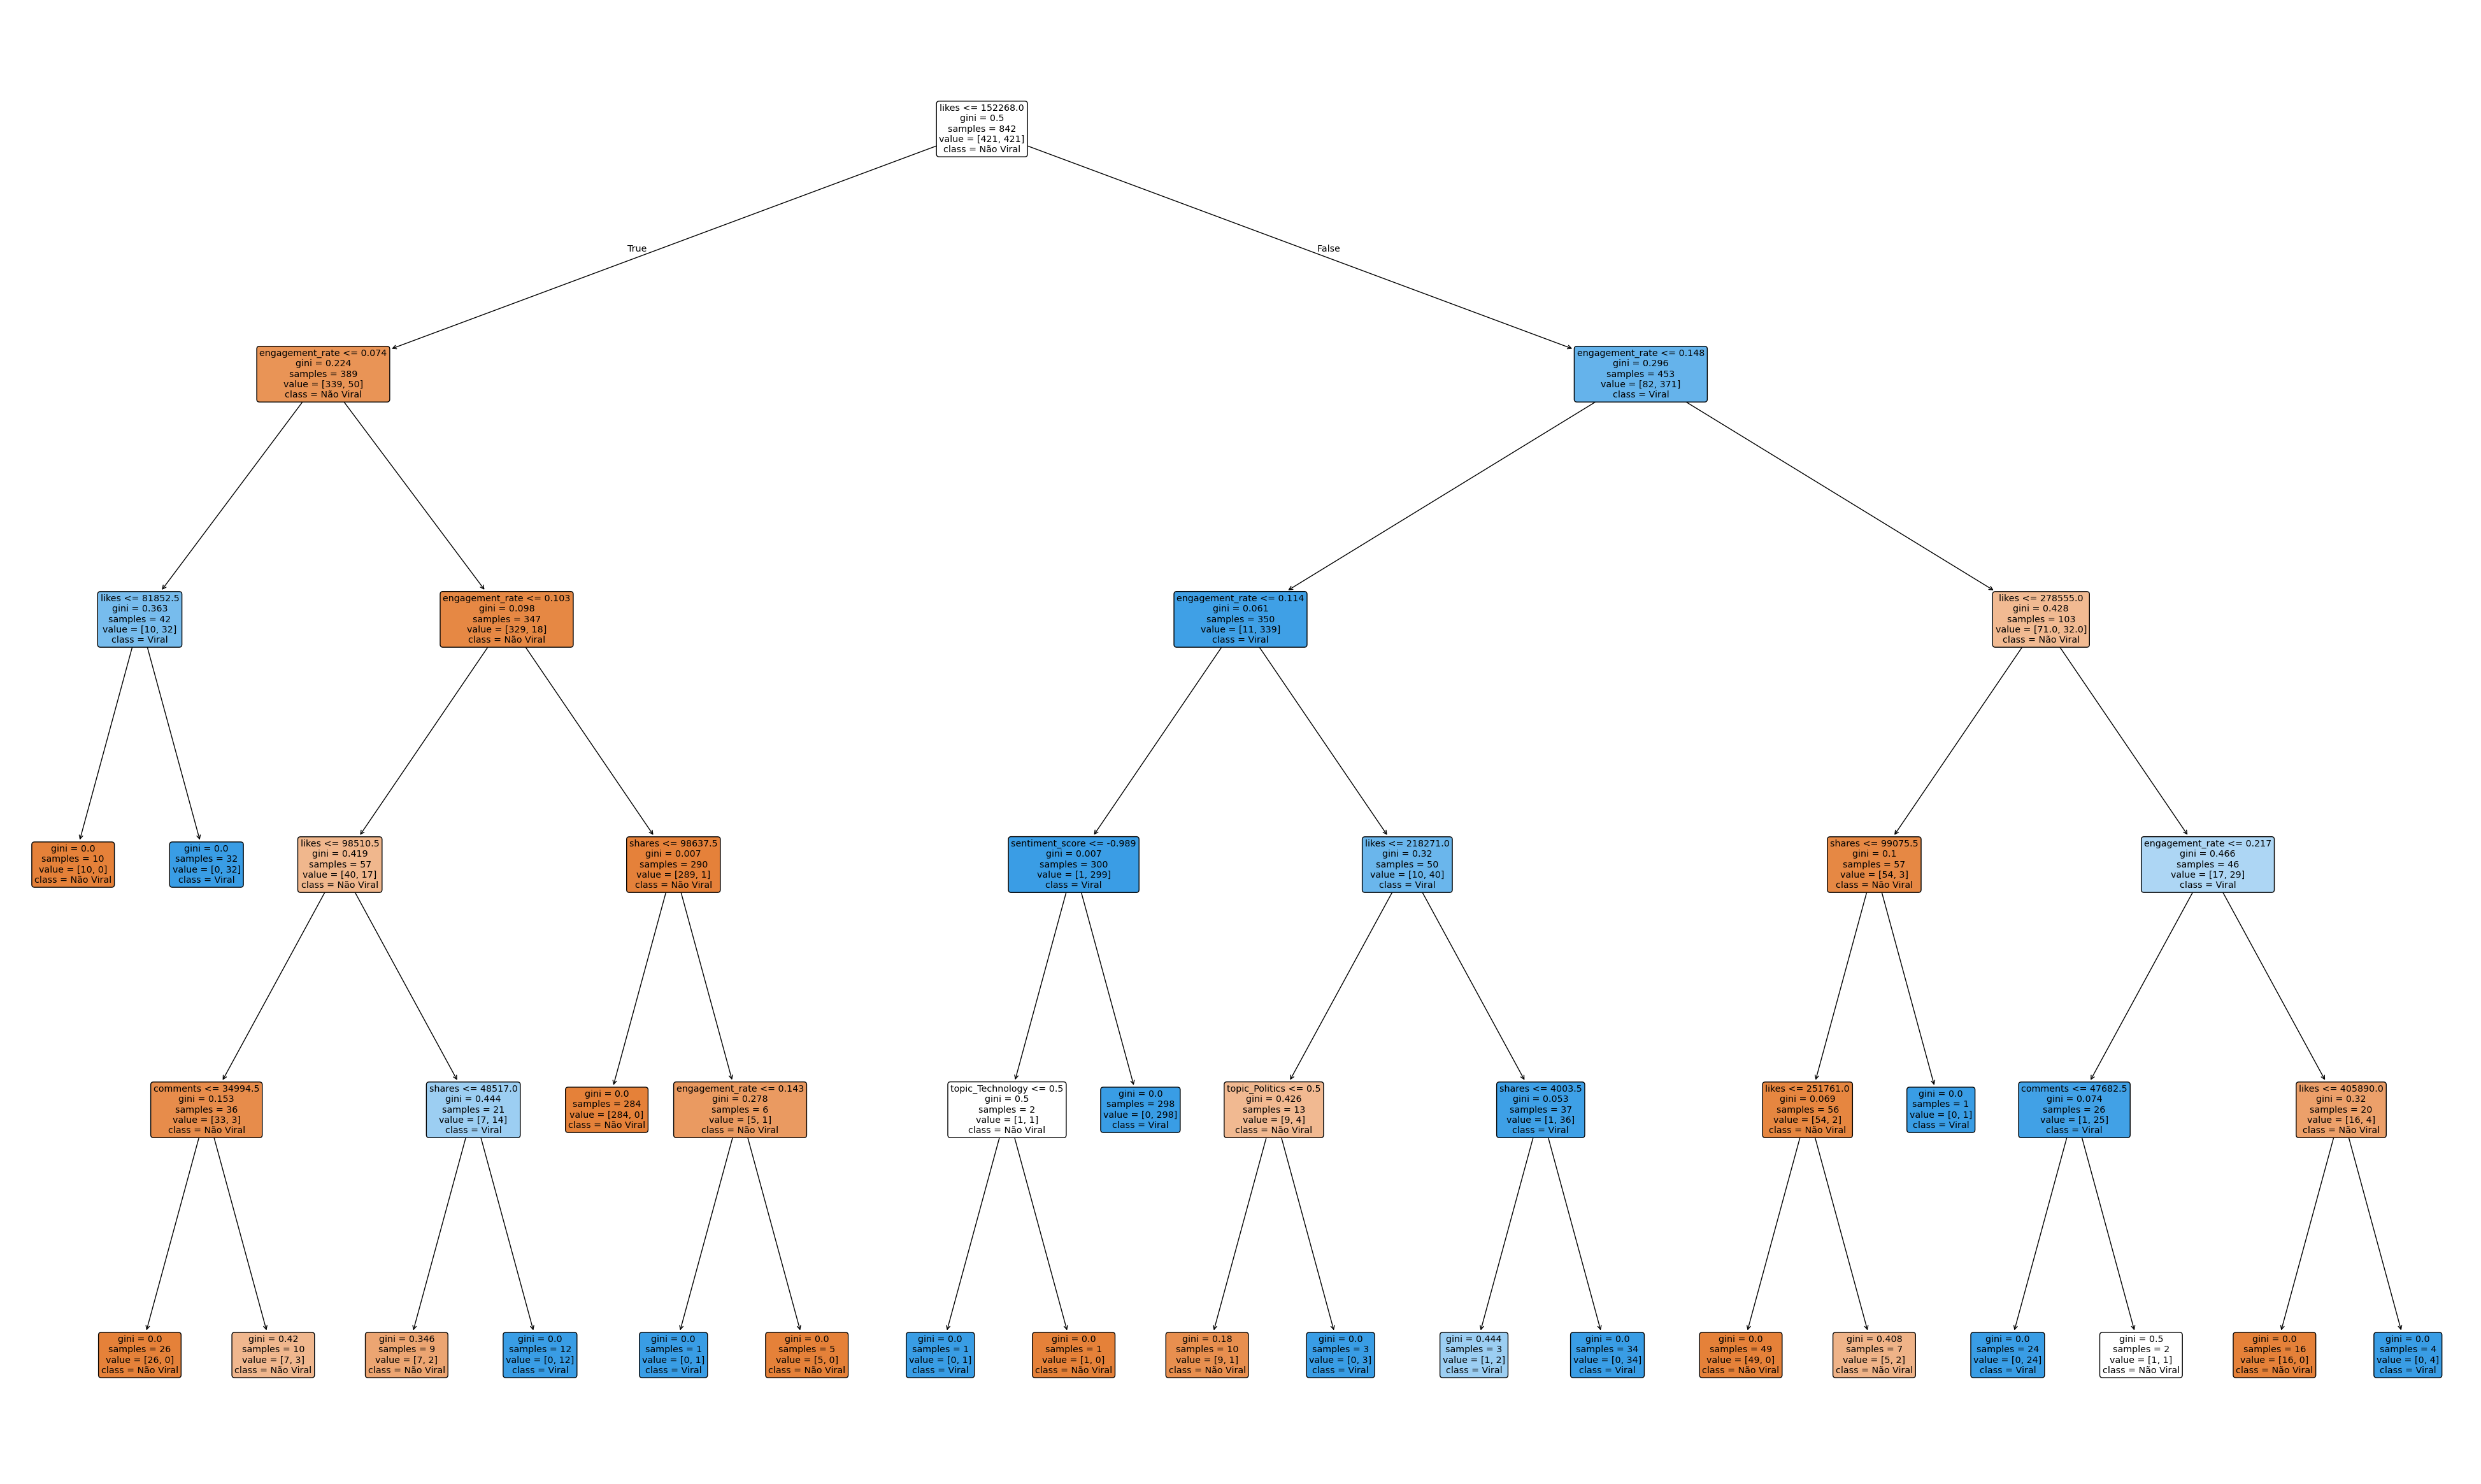

In [28]:
plt.figure(figsize=(50,30))
plot_tree(modelo, feature_names=X.columns, class_names=['Não Viral', 'Viral'], filled=True, rounded=True)
plt.show()

In [29]:
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nPesos das Features (Importância):")
print(importancias.head(10))


Pesos das Features (Importância):
likes               0.631223
engagement_rate     0.327116
shares              0.022101
topic_Politics      0.009192
comments            0.005466
topic_Technology    0.002459
sentiment_score     0.002442
language_es         0.000000
topic_Lifestyle     0.000000
topic_Sports        0.000000
dtype: float64


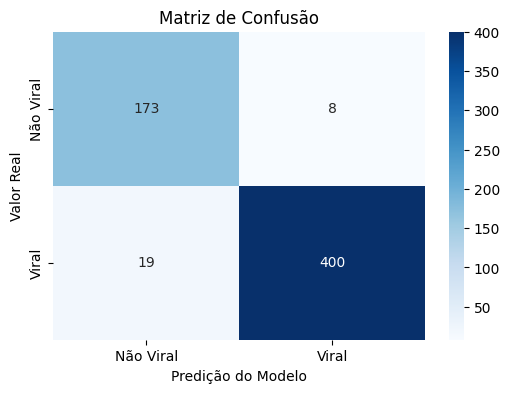

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Viral', 'Viral'], yticklabels=['Não Viral', 'Viral'])
plt.xlabel('Predição do Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusão')
plt.show()

## Conclusão de Viralização de Conteúdo

1.Contexto e Diagnóstico dos Dados O estudo foi fundamentado em um conjunto de dados diversificado, abrangendo múltiplas plataformas (Instagram, X, YouTube Shorts) e métricas de desempenho. A análise inicial revelou um cenário de desbalanceamento de classes, onde aproximadamente 69,90% dos registros foram classificados como virais. Este dado é crucial, pois indica que o modelo deve ser treinado com técnicas específicas (como Undersampling ou ajuste de pesos) para evitar o viés em favor da classe majoritária.

2.Desempenho do Modelo e Métricas Durante o desenvolvimento, observou-se que a acurácia isolada não é um indicador fiel de sucesso devido ao desbalanceamento citado. O uso da Matriz de Confusão e de métricas como Precision, Recall e F1-Score foi identificado como o caminho necessário para garantir que o modelo não apenas "chute" o resultado mais comum, mas que realmente aprenda as características que diferenciam um post comum de um viral.

3.O Papel das Variáveis Temporais e de Texto Uma descoberta metodológica importante foi a necessidade de Engenharia de Features:

Temporalidade: A simples existência de uma data de postagem não é suficiente; é necessário extrair o mês, o dia da semana e o horário para captar padrões de comportamento da audiência.

Hashtags: A transformação de strings de hashtags em variáveis binárias (através de técnicas como One-Hot Encoding) permite que o modelo quantifique o peso individual de cada palavra-chave no potencial de viralização.

De modo geral este estudo fornece a base técnica para a criação de um modelo preditivo capaz de orientar estratégias de conteúdo, transformando dados brutos em inteligência acionável para o crescimento orgânico em redes sociais.